# Predator–Prey Modelling (CITS4403 Project)

**Authors:** Su-Yeon Yang, Jiaren Zhu
**Date:** 2025-10-01

## Setup

In [1]:
# Imports (no seaborn; matplotlib only; avoid styles/colors)
import math, random, statistics, itertools
from dataclasses import dataclass
from typing import Tuple, List, Dict
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
def set_seed(s: int):
    random.seed(s)
    np.random.seed(s)

set_seed(RANDOM_SEED)

## Model Overview and Assumptions
This project includes two complementary modeling approaches:

1. **ODE Baseline (Lotka–Volterra):** Represents well-mixed predator–prey interactions without spatial structure. Used solely for comparison.
2. **Spatial ABM (Toroidal Grid):**
- Each grid cell can contain at most one agent (prey or predator).
- **Prey:** move randomly, reproduce with a given probability, and die if eaten.
- **Predators:** move, consume prey to gain energy, reproduce after successful hunts, and die if their energy drops to zero.
- **Innovation 1 – Spatial Heterogeneity (Refugia):** Some cells are refugia where predators’ hunting success is reduced; prey prefer moving into refugia.
- **Innovation 2 – Adaptive Prey Behavior:** When recent local predation events are high, prey temporarily increase their movement radius from 1 to 2.

**Metrics**
- Time series of predator and prey population sizes.
- Extinction probability across repeated runs.
- Mean ± 95% CI for population trajectories.

## ODE Baseline (Lotka–Volterra)

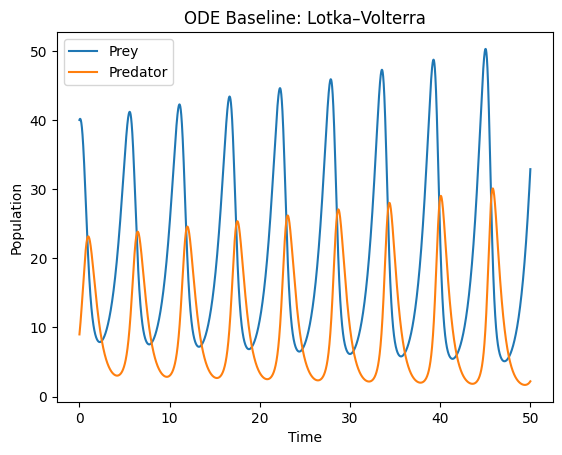

In [2]:
@dataclass
class ODEParams:
    alpha: float = 1.0   # prey birth
    beta: float = 0.1    # predation
    delta: float = 0.075 # efficiency
    gamma: float = 1.5   # predator death
    dt: float = 0.01
    t_end: float = 50.0

def lotka_volterra(x0=40., y0=9., params: ODEParams = ODEParams()):
    n_steps = int(params.t_end / params.dt)
    X = np.zeros(n_steps+1); Y = np.zeros(n_steps+1); T = np.zeros(n_steps+1)
    X[0] = x0; Y[0] = y0
    for i in range(n_steps):
        x, y = X[i], Y[i]
        dx = params.alpha*x - params.beta*x*y
        dy = params.delta*x*y - params.gamma*y
        X[i+1] = max(0.0, x + params.dt*dx)
        Y[i+1] = max(0.0, y + params.dt*dy)
        T[i+1] = T[i] + params.dt
    return T, X, Y

# Smoke test plot
T, X, Y = lotka_volterra()
plt.figure()
plt.plot(T, X, label='Prey')
plt.plot(T, Y, label='Predator')
plt.title('ODE Baseline: Lotka–Volterra')
plt.xlabel('Time'); plt.ylabel('Population')
plt.legend(); plt.show()

## Spatial Agent-Based Model (ABM)

In [3]:
EMPTY = 0
PREY = 1
PRED = 2

@dataclass
class ABMParams:
    width: int = 60
    height: int = 60
    steps: int = 400
    init_prey: int = 900
    init_pred: int = 300
    p_birth_prey: float = 0.05
    p_birth_pred: float = 0.02
    prey_move_range: int = 1
    pred_move_range: int = 1
    pred_init_energy: int = 5
    pred_energy_gain: int = 3
    pred_energy_cost: int = 1
    refugia_fraction: float = 0.15
    refugia_pred_penalty: float = 0.5
    adaptive_window: int = 5

def torus_coords(x, y, W, H):
    return x % W, y % H

def neighbors(x, y, W, H, r=1):
    coords = []
    for dx in range(-r, r+1):
        for dy in range(-r, r+1):
            if dx == 0 and dy == 0: 
                continue
            nx, ny = torus_coords(x+dx, y+dy, W, H)
            coords.append((nx, ny))
    return coords

def init_world(p: ABMParams):
    W, H = p.width, p.height
    grid = np.zeros((H, W), dtype=np.int8)
    energy = np.zeros((H, W), dtype=np.int16)
    refugia = np.zeros((H, W), dtype=np.int8)

    # refugia placement
    n_refugia = int(p.refugia_fraction * W * H)
    idx = np.random.choice(W*H, size=n_refugia, replace=False)
    for flat in idx:
        y, x = divmod(flat, W)
        refugia[y, x] = 1

    # place agents
    cells = np.arange(W*H)
    np.random.shuffle(cells)
    # Prey first
    for flat in cells[:p.init_prey]:
        y, x = divmod(flat, W)
        grid[y, x] = PREY
    # Predators
    for flat in cells[p.init_prey:p.init_prey+p.init_pred]:
        y, x = divmod(flat, W)
        grid[y, x] = PRED
        energy[y, x] = 5

    recent_pred = np.zeros((H, W), dtype=np.int16)
    return grid, energy, refugia, recent_pred

def step(world, p: ABMParams):
    grid, energy, refugia, recent = world
    H, W = grid.shape
    new_grid = grid.copy()
    new_energy = energy.copy()
    new_recent = (recent * 0.9).astype(np.int16)  # decay

    # PREY
    order = np.random.permutation(H*W)
    for flat in order:
        y, x = divmod(flat, W)
        if grid[y, x] != PREY: 
            continue
        # adaptive move if recent predation high
        move_r = p.prey_move_range + (1 if recent[y, x] >= p.adaptive_window else 0)
        nbrs = neighbors(x, y, W, H, r=move_r)
        np.random.shuffle(nbrs)
        target = None; best_is_ref = -1
        for nx, ny in nbrs:
            if new_grid[ny, nx] == EMPTY:
                is_ref = refugia[ny, nx]
                if is_ref > best_is_ref:
                    best_is_ref = is_ref
                    target = (nx, ny)
        if target:
            nx, ny = target
            new_grid[y, x] = EMPTY
            new_grid[ny, nx] = PREY
            # reproduction
            if np.random.rand() < p.p_birth_prey:
                new_grid[y, x] = PREY

    # PRED
    order = np.random.permutation(H*W)
    for flat in order:
        y, x = divmod(flat, W)
        if grid[y, x] != PRED:
            continue
        # energy upkeep
        new_energy[y, x] -= p.pred_energy_cost
        if new_energy[y, x] <= 0:
            new_grid[y, x] = EMPTY
            new_energy[y, x] = 0
            continue
        # move / hunt
        nbrs = neighbors(x, y, W, H, r=p.pred_move_range)
        np.random.shuffle(nbrs)
        moved = False
        for nx, ny in nbrs:
            if new_grid[ny, nx] == PREY:
                # predation success reduced in refugia
                mult = (1.0 - p.refugia_pred_penalty) if refugia[ny, nx] else 1.0
                if np.random.rand() <= mult:
                    # eat
                    new_grid[ny, nx] = PRED
                    new_grid[y, x] = EMPTY
                    new_energy[ny, nx] = new_energy[y, x] + p.pred_energy_gain
                    new_energy[y, x] = 0
                    new_recent[ny, nx] += 1
                    # reproduction after hunt
                    if np.random.rand() < p.p_birth_pred:
                        new_grid[y, x] = PRED
                        new_energy[y, x] = 5
                    moved = True
                    break
            elif new_grid[ny, nx] == EMPTY:
                new_grid[ny, nx] = PRED
                new_grid[y, x] = EMPTY
                new_energy[ny, nx] = new_energy[y, x]
                new_energy[y, x] = 0
                moved = True
                break
    return (new_grid, new_energy, refugia, new_recent)

def run_abm(p: ABMParams, seed: int = 0):
    set_seed(seed)
    world = init_world(p)
    prey_ts = []
    pred_ts = []
    for t in range(p.steps):
        prey_ts.append(np.count_nonzero(world[0] == PREY))
        pred_ts.append(np.count_nonzero(world[0] == PRED))
        world = step(world, p)
    prey_ts.append(np.count_nonzero(world[0] == PREY))
    pred_ts.append(np.count_nonzero(world[0] == PRED))
    return np.array(prey_ts), np.array(pred_ts)

## Experiments

In [4]:
def replicate_abm(p: ABMParams, n_seeds=12):
    seeds = list(range(1, n_seeds+1))
    prey_list, pred_list = [], []
    for s in seeds:
        P, Q = run_abm(p, seed=s)
        prey_list.append(P); pred_list.append(Q)
    return np.vstack(prey_list), np.vstack(pred_list)

def mean_ci(arr2d):
    mean = arr2d.mean(axis=0)
    std = arr2d.std(axis=0, ddof=1)
    n = arr2d.shape[0]
    half = 1.96 * std / math.sqrt(n) if n>1 else np.zeros_like(mean)
    return mean, mean-half, mean+half

params_no_refugia = ABMParams(refugia_fraction=0.0, adaptive_window=9999)
params_with_innov = ABMParams(refugia_fraction=0.15, adaptive_window=5)

print("Running ABM: no refugia/adapt ...")
prey1, pred1 = replicate_abm(params_no_refugia, n_seeds=12)
print("Running ABM: refugia + adaptive ...")
prey2, pred2 = replicate_abm(params_with_innov, n_seeds=12)

prey1_m, prey1_lo, prey1_hi = mean_ci(prey1)
pred1_m, pred1_lo, pred1_hi = mean_ci(pred1)
prey2_m, prey2_lo, prey2_hi = mean_ci(prey2)
pred2_m, pred2_lo, pred2_hi = mean_ci(pred2)

print("Done.")

Running ABM: no refugia/adapt ...
Running ABM: refugia + adaptive ...
Done.


## Plots

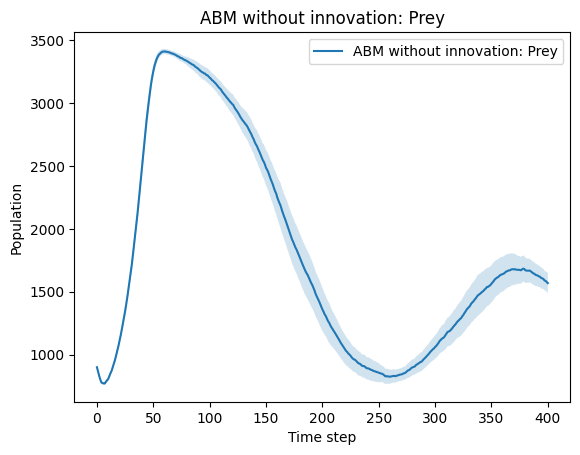

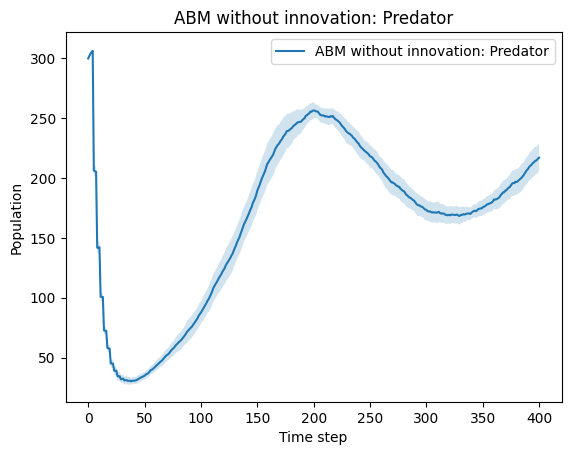

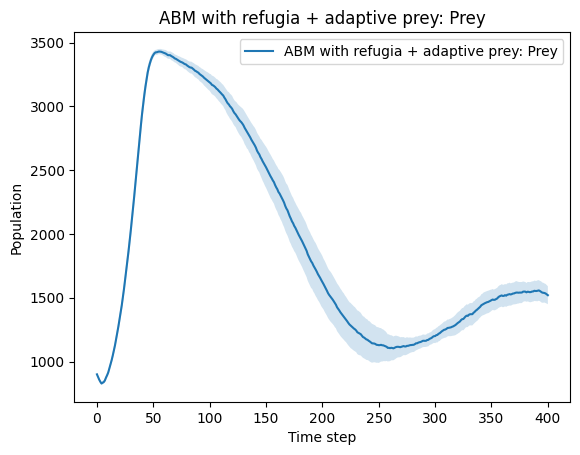

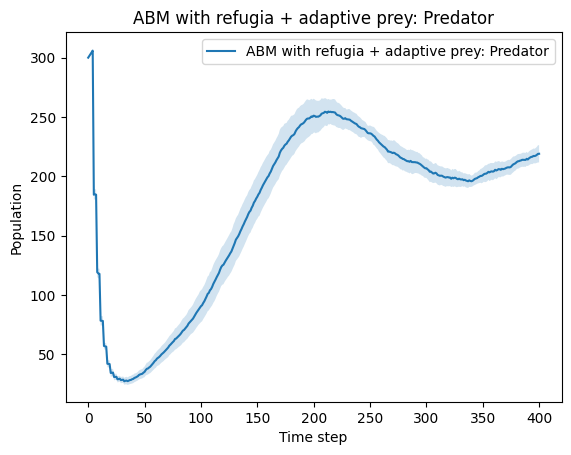

In [5]:
def plot_with_ci(mean, lo, hi, label):
    plt.figure()
    plt.fill_between(range(len(mean)), lo, hi, alpha=0.2)
    plt.plot(mean, label=label)
    plt.xlabel('Time step'); plt.ylabel('Population')
    plt.title(label); plt.legend(); plt.show()

plot_with_ci(prey1_m, prey1_lo, prey1_hi, 'ABM without innovation: Prey')
plot_with_ci(pred1_m, pred1_lo, pred1_hi, 'ABM without innovation: Predator')
plot_with_ci(prey2_m, prey2_lo, prey2_hi, 'ABM with refugia + adaptive prey: Prey')
plot_with_ci(pred2_m, pred2_lo, pred2_hi, 'ABM with refugia + adaptive prey: Predator')

## Extinction Probability

In [6]:
def extinction_prob(mat, threshold=1):
    final = mat[:, -1]
    return (final < threshold).mean()

print("Extinction probability (no refugia/adapt):")
print("  Prey:", extinction_prob(prey1))
print("  Pred:", extinction_prob(pred1))
print("Extinction probability (with refugia+adapt):")
print("  Prey:", extinction_prob(prey2))
print("  Pred:", extinction_prob(pred2))

Extinction probability (no refugia/adapt):
  Prey: 0.0
  Pred: 0.0
Extinction probability (with refugia+adapt):
  Prey: 0.0
  Pred: 0.0


## ODE vs ABM (Representative Run)

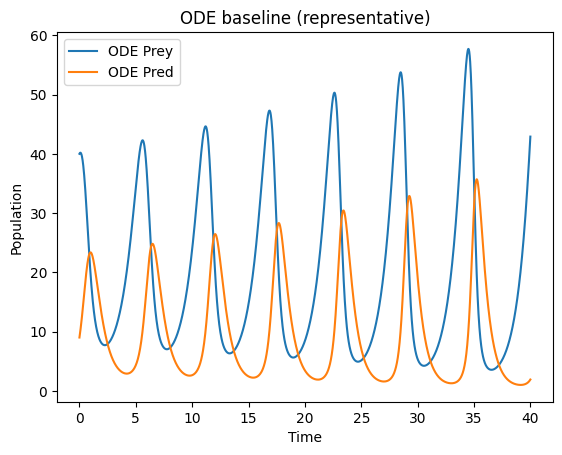

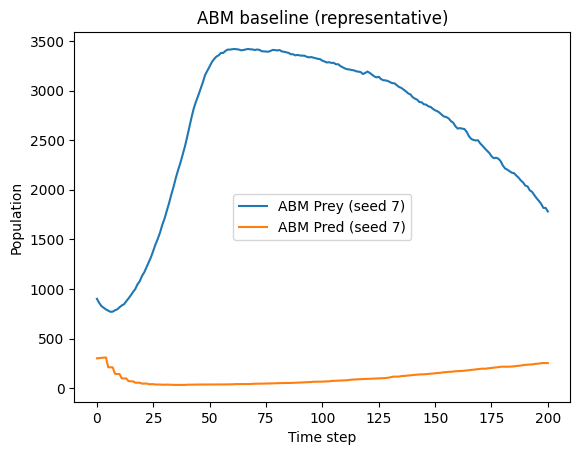

In [7]:
T, X, Y = lotka_volterra(x0=40, y0=9, params=ODEParams(t_end=40, dt=0.02))
P, Q = run_abm(ABMParams(steps=200, refugia_fraction=0.0, adaptive_window=9999), seed=7)

plt.figure()
plt.plot(T, X, label='ODE Prey')
plt.plot(T, Y, label='ODE Pred')
plt.xlabel('Time'); plt.ylabel('Population')
plt.title('ODE baseline (representative)')
plt.legend(); plt.show()

plt.figure()
plt.plot(P, label='ABM Prey (seed 7)')
plt.plot(Q, label='ABM Pred (seed 7)')
plt.xlabel('Time step'); plt.ylabel('Population')
plt.title('ABM baseline (representative)')
plt.legend(); plt.show()

## Reproducibility and Parameters
- All stochastic simulations use fixed seeds; increase `n_seeds` for more robust statistics.
- Core parameters are centralized in the `ABMParams` dataclass.
- Re-running this notebook will regenerate all results and figures.